# Notebook 32 — Cross-parameter gain–margin transfer

## Goal

Test whether the gain–margin admissibility structure found in Chen2020 transfers to other PyBaMM parameter sets under set-rebased DC–AC excitation.

Core question:

> Does the relationship between raw timing gain and negative-electrode plating-margin admissibility remain similar across Chen2020, Ecker2015, and ORegan2022?

## Scientific context

Notebook 30 showed that DC–AC can create equal-Q microstate differences, but timing gain was geometry-dominated in the Chen2020 model hierarchy.

Notebook 31 added negative-electrode plating-margin admissibility. In Chen2020 / DFN, high-amplitude `0.3C + 0.7C` DC–AC violated the hard 0 mV negative-electrode potential proxy. At fixed `1.5τ_set`, amplitude reduction localized the full-protocol hard-margin boundary near:

```text
AC ≈ 0.386C
peak current ≈ 0.686C
```

Notebook 32 tests whether that gain–margin boundary is parameter-set specific or transferable.

## Protocol / study design

Parameter sets:

- Chen2020
- Ecker2015
- ORegan2022

Model:

- DFN

Frequency:

- set-rebased `1.5τ_set`
- `τ_ref,set` from Day17 `tau2_biexp`

Current protocols:

- DC baseline: `0.3C`
- DC–AC: `0.3C + AC`
- AC scan: `0.1C`, `0.2C`, `0.3C`, `0.36C`, `0.38C`, `0.40C`, `0.5C`, `0.7C`

## Margin classes

| Class | Criterion |
|---|---|
| `safe_margin` | min U_NE_vs_Li > 50 mV |
| `near_boundary` | 0 mV < min U_NE_vs_Li <= 50 mV |
| `risk_flag` | min U_NE_vs_Li <= 0 mV |

The 50 mV threshold is an audit buffer, not a universal physical constant.

## Interpretation boundary

This notebook is a transferability screen. It does not prove plating occurrence or absence. It audits a thermodynamic negative-electrode potential proxy under a virtual three-electrode PyBaMM setting.


In [1]:
# Cell 1 — Imports and project paths（导入库与项目路径）

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pybamm

warnings.filterwarnings("default")

REPO = Path("/Users/louislu/pybamm-dcac-superimposed")
DATA_DIR = REPO / "data"
FIG_DIR = REPO / "figures"
DOCS_TABLE_DIR = REPO / "docs" / "tables"
DOCS_FIG_DIR = REPO / "docs" / "figures"

for p in [DATA_DIR, FIG_DIR, DOCS_TABLE_DIR, DOCS_FIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("[OK] repo:", REPO)
print("[OK] pybamm version:", pybamm.__version__)


[OK] repo: /Users/louislu/pybamm-dcac-superimposed
[OK] pybamm version: 26.3.1


In [2]:
# Cell 2 — Load tau references and define cross-parameter protocols（读取时间常数并定义跨参数集协议）

PARAMETER_SETS = ["Chen2020", "Ecker2015", "ORegan2022"]
MODEL_TYPE = "DFN"

DC_C = 0.3
AC_C_SCAN = [0.1, 0.2, 0.3, 0.36, 0.38, 0.40, 0.5, 0.7]
TAU_FACTOR_SET = 1.5

tau_matrix_path = DATA_DIR / "day17_step1_tau_ref_descriptor_matrix.csv"
tau_matrix_df = pd.read_csv(tau_matrix_path)

tau_ref_df = (
    tau_matrix_df.loc[tau_matrix_df["param_set"].isin(PARAMETER_SETS),
                      ["param_set", "chem_tag", "tau2_biexp"]]
    .rename(columns={"param_set": "parameter_set", "tau2_biexp": "tau_ref_set_s"})
    .copy()
)

missing = sorted(set(PARAMETER_SETS) - set(tau_ref_df["parameter_set"]))
if missing:
    raise ValueError(f"Missing tau_ref for parameter sets: {missing}")

display(tau_ref_df)

def f_from_tau_factor(tau_factor, tau_ref_s):
    return 1.0 / (2.0 * np.pi * tau_factor * tau_ref_s)

def ac_label(ac_c):
    return str(ac_c).replace(".", "p")

rows = []

for _, tr in tau_ref_df.iterrows():
    pset = tr["parameter_set"]
    tau_ref_s = float(tr["tau_ref_set_s"])
    f_hz = f_from_tau_factor(TAU_FACTOR_SET, tau_ref_s)
    period_s = 1.0 / f_hz

    rows.append({
        "parameter_set": pset,
        "chem_tag": tr["chem_tag"],
        "model_type": MODEL_TYPE,
        "condition": f"{pset}_DFN_DC03",
        "protocol_type": "DC",
        "dc_c": DC_C,
        "ac_c": 0.0,
        "peak_c": DC_C,
        "tau_factor_set": np.nan,
        "tau_ref_set_s": tau_ref_s,
        "f_Hz": np.nan,
        "period_s": np.nan,
        "omega_tau_set": np.nan,
        "kappa": 0.0,
    })

    for ac_c in AC_C_SCAN:
        rows.append({
            "parameter_set": pset,
            "chem_tag": tr["chem_tag"],
            "model_type": MODEL_TYPE,
            "condition": f"{pset}_DFN_DC03_AC{ac_label(ac_c)}_1p5tauSet",
            "protocol_type": "DCAC",
            "dc_c": DC_C,
            "ac_c": ac_c,
            "peak_c": DC_C + ac_c,
            "tau_factor_set": TAU_FACTOR_SET,
            "tau_ref_set_s": tau_ref_s,
            "f_Hz": f_hz,
            "period_s": period_s,
            "omega_tau_set": 1.0 / TAU_FACTOR_SET,
            "kappa": ac_c / DC_C,
        })

protocol_df = pd.DataFrame(rows)

out = DATA_DIR / "day32_cross_parameter_protocol_table.csv"
protocol_df.to_csv(out, index=False)

print("[OK] saved:", out)
display(protocol_df)


,parameter_set,chem_tag,tau_ref_set_s
1,Chen2020,LG M50 NMC811-Si,36.316532
2,Ecker2015,Kokam-Ecker Co-rich Mn-free,16.517654
7,ORegan2022,LG M50 NMC811-Si,53.575426


[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day32_cross_parameter_protocol_table.csv


,parameter_set,chem_tag,model_type,condition,protocol_type,dc_c,ac_c,peak_c,tau_factor_set,tau_ref_set_s,f_Hz,period_s,omega_tau_set,kappa
0,Chen2020,LG M50 NMC811-Si,DFN,Chen2020_DFN_DC03,DC,0.3,0.00,0.30,NaN,36.316532,NaN,NaN,NaN,0.000000
1,Chen2020,LG M50 NMC811-Si,DFN,Chen2020_DFN_DC03_AC0p1_1p5tauSet,DCAC,0.3,0.10,0.40,1.5,36.316532,0.002922,342.275253,0.666667,0.333333
2,Chen2020,LG M50 NMC811-Si,DFN,Chen2020_DFN_DC03_AC0p2_1p5tauSet,DCAC,0.3,0.20,0.50,1.5,36.316532,0.002922,342.275253,0.666667,0.666667
3,Chen2020,LG M50 NMC811-Si,DFN,Chen2020_DFN_DC03_AC0p3_1p5tauSet,DCAC,0.3,0.30,0.60,1.5,36.316532,0.002922,342.275253,0.666667,1.000000
4,Chen2020,LG M50 NMC811-Si,DFN,Chen2020_DFN_DC03_AC0p36_1p5tauSet,DCAC,0.3,0.36,0.66,1.5,36.316532,0.002922,342.275253,0.666667,1.200000
5,Chen2020,LG M50 NMC811-Si,DFN,Chen2020_DFN_DC03_AC0p38_1p5tauSet,DCAC,0.3,0.38,0.68,1.5,36.316532,0.002922,342.275253,0.666667,1.266667
6,Chen2020,LG M50 NMC811-Si,DFN,Chen2020_DFN_DC03_AC0p4_1p5tauSet,DCAC,0.3,0.40,0.70,1.5,36.316532,0.002922,342.275253,0.666667,1.333333
7,Chen2020,LG M50 NMC811-Si,DFN,Chen2020_DFN_DC03_AC0p5_1p5tauSet,DCAC,0.3,0.50,0.80,1.5,36.316532,0.002922,342.275253,0.666667,1.666667
8,Chen2020,LG M50 NMC811-Si,DFN,Chen2020_DFN_DC03_AC0p7_1p5tauSet,DCAC,0.3,0.70,1.00,1.5,36.316532,0.002922,342.275253,0.666667,2.333333
9,Ecker2015,Kokam-Ecker Co-rich Mn-free,DFN,Ecker2015_DFN_DC03,DC,0.3,0.00,0.30,NaN,16.517654,NaN,NaN,NaN,0.000000


In [3]:
# Cell 3 — Simulation utilities（仿真工具函数）

def make_model(model_type="DFN"):
    if model_type == "DFN":
        return pybamm.lithium_ion.DFN({"thermal": "isothermal"})
    if model_type == "SPMe":
        return pybamm.lithium_ion.SPMe({"thermal": "isothermal"})
    if model_type == "SPM":
        return pybamm.lithium_ion.SPM({"thermal": "isothermal"})
    raise ValueError(f"Unknown model_type: {model_type}")

def make_parameter_values_with_current(parameter_set, dc_c, ac_c, f_hz):
    pv = pybamm.ParameterValues(parameter_set)
    q_ah = float(pv["Nominal cell capacity [A.h]"])

    i_dc_abs = dc_c * q_ah
    i_ac_abs = ac_c * q_ah

    if ac_c == 0 or f_hz is None or pd.isna(f_hz):
        def current_fun(t):
            return -i_dc_abs + 0 * t
    else:
        def current_fun(t):
            return -i_dc_abs - i_ac_abs * pybamm.sin(2 * np.pi * f_hz * t)

    pv.update({"Current function [A]": current_fun}, check_already_exists=False)

    meta = {
        "parameter_set": parameter_set,
        "nominal_capacity_Ah": q_ah,
        "dc_c": dc_c,
        "ac_c": ac_c,
        "i_dc_A": i_dc_abs,
        "i_ac_A": i_ac_abs,
        "f_Hz": f_hz,
        "phase_convention": "charge_first",
    }
    return pv, meta

def cumulative_trapezoid_np(y, x):
    y = np.asarray(y, dtype=float).reshape(-1)
    x = np.asarray(x, dtype=float).reshape(-1)
    if len(y) != len(x):
        raise ValueError("x and y length mismatch")
    if len(y) < 2:
        return np.zeros_like(y)
    dx = np.diff(x)
    area = 0.5 * (y[:-1] + y[1:]) * dx
    return np.concatenate([[0.0], np.cumsum(area)])

def extract_basic_timeseries(sol):
    t = np.asarray(sol.t, dtype=float)
    I_py = np.asarray(sol["Current [A]"](t), dtype=float).reshape(-1)
    V = np.asarray(sol["Terminal voltage [V]"](t), dtype=float).reshape(-1)

    I_charge = -I_py
    Q_Ah = cumulative_trapezoid_np(I_charge, t) / 3600.0

    return pd.DataFrame({
        "t_s": t,
        "I_py_A": I_py,
        "I_charge_A": I_charge,
        "V_terminal_V": V,
        "Q_net_Ah": Q_Ah,
    })

def run_simulation(protocol_row, initial_soc=0.05, max_time_s=24000, n_eval=5000):
    model = make_model(protocol_row["model_type"])
    pv, meta = make_parameter_values_with_current(
        parameter_set=protocol_row["parameter_set"],
        dc_c=float(protocol_row["dc_c"]),
        ac_c=float(protocol_row["ac_c"]),
        f_hz=None if pd.isna(protocol_row["f_Hz"]) else float(protocol_row["f_Hz"]),
    )

    sim = pybamm.Simulation(model, parameter_values=pv)
    t_eval = np.linspace(0.0, max_time_s, n_eval)
    sol = sim.solve(t_eval=t_eval, initial_soc=initial_soc)
    ts = extract_basic_timeseries(sol)
    return sim, sol, ts, meta

print("[OK] simulation utilities ready")


[OK] simulation utilities ready


In [4]:
# Cell 4 — Run cross-parameter simulations（运行跨参数集仿真）

solutions = {}
run_rows = []

for _, row in protocol_df.iterrows():
    cond = row["condition"]
    print(f"\n[RUN] {cond}")

    try:
        sim, sol, ts, meta = run_simulation(row.to_dict())
        solutions[cond] = {
            "sim": sim,
            "sol": sol,
            "ts": ts,
            "meta": meta,
            "protocol": row.to_dict(),
        }
        run_rows.append({
            "parameter_set": row["parameter_set"],
            "condition": cond,
            "status": "ok",
            "termination": str(sol.termination),
            "t_end_s": float(ts["t_s"].iloc[-1]),
            "t_end_min": float(ts["t_s"].iloc[-1] / 60),
            "Q_end_Ah": float(ts["Q_net_Ah"].iloc[-1]),
            "V_end_V": float(ts["V_terminal_V"].iloc[-1]),
            "I_charge_min_A": float(ts["I_charge_A"].min()),
            "I_charge_max_A": float(ts["I_charge_A"].max()),
            "dc_c": row["dc_c"],
            "ac_c": row["ac_c"],
            "peak_c": row["peak_c"],
            "tau_factor_set": row["tau_factor_set"],
            "error": "",
        })
        print("[OK]", cond, "| termination:", sol.termination)
    except Exception as e:
        run_rows.append({
            "parameter_set": row["parameter_set"],
            "condition": cond,
            "status": "failed",
            "termination": "",
            "t_end_s": np.nan,
            "t_end_min": np.nan,
            "Q_end_Ah": np.nan,
            "V_end_V": np.nan,
            "I_charge_min_A": np.nan,
            "I_charge_max_A": np.nan,
            "dc_c": row["dc_c"],
            "ac_c": row["ac_c"],
            "peak_c": row["peak_c"],
            "tau_factor_set": row["tau_factor_set"],
            "error": repr(e),
        })
        print("[FAILED]", cond, repr(e))

run_summary_df = pd.DataFrame(run_rows)

out = DATA_DIR / "day32_cross_parameter_run_summary.csv"
run_summary_df.to_csv(out, index=False)

print("[OK] saved:", out)
display(run_summary_df)



[RUN] Chen2020_DFN_DC03
[OK] Chen2020_DFN_DC03 | termination: event: Maximum voltage [V]

[RUN] Chen2020_DFN_DC03_AC0p1_1p5tauSet
[OK] Chen2020_DFN_DC03_AC0p1_1p5tauSet | termination: event: Maximum voltage [V]

[RUN] Chen2020_DFN_DC03_AC0p2_1p5tauSet
[OK] Chen2020_DFN_DC03_AC0p2_1p5tauSet | termination: event: Maximum voltage [V]

[RUN] Chen2020_DFN_DC03_AC0p3_1p5tauSet
[OK] Chen2020_DFN_DC03_AC0p3_1p5tauSet | termination: event: Maximum voltage [V]

[RUN] Chen2020_DFN_DC03_AC0p36_1p5tauSet
[OK] Chen2020_DFN_DC03_AC0p36_1p5tauSet | termination: event: Maximum voltage [V]

[RUN] Chen2020_DFN_DC03_AC0p38_1p5tauSet
[OK] Chen2020_DFN_DC03_AC0p38_1p5tauSet | termination: event: Maximum voltage [V]

[RUN] Chen2020_DFN_DC03_AC0p4_1p5tauSet
[OK] Chen2020_DFN_DC03_AC0p4_1p5tauSet | termination: event: Maximum voltage [V]

[RUN] Chen2020_DFN_DC03_AC0p5_1p5tauSet
[OK] Chen2020_DFN_DC03_AC0p5_1p5tauSet | termination: event: Maximum voltage [V]

[RUN] Chen2020_DFN_DC03_AC0p7_1p5tauSet
[OK] Chen20

,parameter_set,condition,status,termination,t_end_s,t_end_min,Q_end_Ah,V_end_V,I_charge_min_A,I_charge_max_A,dc_c,ac_c,peak_c,tau_factor_set,error
0,Chen2020,Chen2020_DFN_DC03,ok,event: Maximum voltage [V],10782.909607,179.715160,4.492879,4.2,1.500000e+00,1.500000,0.3,0.00,0.30,NaN,
1,Chen2020,Chen2020_DFN_DC03_AC0p1_1p5tauSet,ok,event: Maximum voltage [V],10653.155331,177.552589,4.441013,4.2,1.000000e+00,2.000000,0.3,0.10,0.40,1.5,
2,Chen2020,Chen2020_DFN_DC03_AC0p2_1p5tauSet,ok,event: Maximum voltage [V],10330.346615,172.172444,4.313115,4.2,5.000000e-01,2.500000,0.3,0.20,0.50,1.5,
3,Chen2020,Chen2020_DFN_DC03_AC0p3_1p5tauSet,ok,event: Maximum voltage [V],9661.819662,161.030328,4.045353,4.2,9.853115e-08,3.000000,0.3,0.30,0.60,1.5,
4,Chen2020,Chen2020_DFN_DC03_AC0p36_1p5tauSet,ok,event: Maximum voltage [V],9325.524778,155.425413,3.912123,4.2,-3.000000e-01,3.300000,0.3,0.36,0.66,1.5,
5,Chen2020,Chen2020_DFN_DC03_AC0p38_1p5tauSet,ok,event: Maximum voltage [V],9317.813665,155.296894,3.906333,4.2,-4.000000e-01,3.400000,0.3,0.38,0.68,1.5,
6,Chen2020,Chen2020_DFN_DC03_AC0p4_1p5tauSet,ok,event: Maximum voltage [V],9312.498817,155.208314,3.902494,4.2,-5.000000e-01,3.500000,0.3,0.40,0.70,1.5,
7,Chen2020,Chen2020_DFN_DC03_AC0p5_1p5tauSet,ok,event: Maximum voltage [V],8975.428074,149.590468,3.771150,4.2,-9.999999e-01,4.000000,0.3,0.50,0.80,1.5,
8,Chen2020,Chen2020_DFN_DC03_AC0p7_1p5tauSet,ok,event: Maximum voltage [V],8627.912611,143.798544,3.633942,4.2,-2.000000e+00,5.000000,0.3,0.70,1.00,1.5,
9,Ecker2015,Ecker2015_DFN_DC03,ok,event: Maximum voltage [V],12283.762068,204.729368,0.159945,4.2,4.687500e-02,0.046875,0.3,0.00,0.30,NaN,


In [5]:
# Cell 5 — Variable availability by parameter set（按参数集审计负极电位变量可用性）

SEARCH_KEYS = [
    "Negative electrode surface potential difference [V]",
    "Negative electrode surface potential difference at separator interface [V]",
    "X-averaged negative electrode surface potential difference [V]",
]

availability_rows = []

for pset in PARAMETER_SETS:
    dc_cond = f"{pset}_DFN_DC03"
    if dc_cond not in solutions:
        availability_rows.append({
            "parameter_set": pset,
            "status": "missing_dc_solution",
            "missing_keys": "",
            "available_keys": "",
        })
        continue

    keys = sorted(list(solutions[dc_cond]["sim"].built_model.variables.keys()))
    missing = [k for k in SEARCH_KEYS if k not in keys]
    available = [k for k in SEARCH_KEYS if k in keys]

    availability_rows.append({
        "parameter_set": pset,
        "status": "ok" if not missing else "missing_required_key",
        "missing_keys": "; ".join(missing),
        "available_keys": "; ".join(available),
    })

availability_df = pd.DataFrame(availability_rows)

out = DATA_DIR / "day32_cross_parameter_margin_variable_availability.csv"
availability_df.to_csv(out, index=False)

print("[OK] saved:", out)
display(availability_df)

if (availability_df["status"] != "ok").any():
    raise RuntimeError("Some parameter sets are missing required plating-margin variables.")


[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day32_cross_parameter_margin_variable_availability.csv


,parameter_set,status,missing_keys,available_keys
0,Chen2020,ok,,Negative electrode surface potential differenc...
1,Ecker2015,ok,,Negative electrode surface potential differenc...
2,ORegan2022,ok,,Negative electrode surface potential differenc...


In [6]:
# Cell 6 — Extract plating-margin timeseries（提取析锂余量时间序列）

NE_SURFACE_KEY = "Negative electrode surface potential difference [V]"
NE_SEPARATOR_KEY = "Negative electrode surface potential difference at separator interface [V]"
NE_XAVG_KEY = "X-averaged negative electrode surface potential difference [V]"

PLATING_MARGIN_SAFE_BUFFER_V = 0.050

def classify_margin(u_v):
    if pd.isna(u_v):
        return "unresolved"
    if u_v <= 0.0:
        return "risk_flag"
    if u_v <= PLATING_MARGIN_SAFE_BUFFER_V:
        return "near_boundary"
    return "safe_margin"

def reduce_variable_to_timeseries(arr, t_s, reducer="mean"):
    arr = np.asarray(arr, dtype=float)
    t_s = np.asarray(t_s, dtype=float)
    n_t = len(t_s)

    if arr.ndim == 0:
        return np.full(n_t, float(arr))
    if arr.ndim == 1:
        if arr.shape[0] == n_t:
            return arr
        return np.full(n_t, np.nanmean(arr))
    if arr.shape[-1] == n_t:
        flat = arr.reshape(-1, n_t)
        axis = 0
    elif arr.shape[0] == n_t:
        flat = arr.reshape(n_t, -1)
        axis = 1
    else:
        raise ValueError(f"Cannot identify time axis: arr.shape={arr.shape}, n_t={n_t}")

    if reducer == "min":
        return np.nanmin(flat, axis=axis)
    if reducer == "mean":
        return np.nanmean(flat, axis=axis)
    if reducer == "max":
        return np.nanmax(flat, axis=axis)
    raise ValueError(reducer)

margin_ts_map = {}
margin_rows = []

for cond, obj in solutions.items():
    sol = obj["sol"]
    ts = obj["ts"].copy()
    t_s = ts["t_s"].to_numpy()

    raw_surface = sol[NE_SURFACE_KEY](t_s)
    ts["U_NE_vs_Li_min_V"] = reduce_variable_to_timeseries(raw_surface, t_s, reducer="min")
    ts["U_NE_vs_Li_mean_V"] = reduce_variable_to_timeseries(raw_surface, t_s, reducer="mean")

    raw_sep = sol[NE_SEPARATOR_KEY](t_s)
    ts["U_NE_vs_Li_separator_V"] = reduce_variable_to_timeseries(raw_sep, t_s, reducer="mean")

    raw_xavg = sol[NE_XAVG_KEY](t_s)
    ts["U_NE_vs_Li_xavg_V"] = reduce_variable_to_timeseries(raw_xavg, t_s, reducer="mean")

    ts["U_NE_margin_min_mV"] = ts["U_NE_vs_Li_min_V"] * 1000.0
    ts["margin_class_inst"] = ts["U_NE_vs_Li_min_V"].apply(classify_margin)

    margin_ts_map[cond] = ts

    margin_rows.append({
        "condition": cond,
        "n_time": len(ts),
        "min_U_NE_mV": float(ts["U_NE_margin_min_mV"].min()),
        "fraction_time_below_50mV": float((ts["U_NE_vs_Li_min_V"] <= 0.050).mean()),
        "fraction_time_below_0mV": float((ts["U_NE_vs_Li_min_V"] <= 0.0).mean()),
        "status": "ok",
    })

margin_extraction_df = pd.DataFrame(margin_rows)

out = DATA_DIR / "day32_cross_parameter_margin_extraction_audit.csv"
margin_extraction_df.to_csv(out, index=False)

print("[OK] saved:", out)
display(margin_extraction_df)


[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day32_cross_parameter_margin_extraction_audit.csv


,condition,n_time,min_U_NE_mV,fraction_time_below_50mV,fraction_time_below_0mV,status
0,Chen2020_DFN_DC03,12159,37.280562,0.219837,0.000000,ok
1,Chen2020_DFN_DC03_AC0p1_1p5tauSet,13177,25.760879,0.155802,0.000000,ok
2,Chen2020_DFN_DC03_AC0p2_1p5tauSet,14264,15.144144,0.142246,0.000000,ok
3,Chen2020_DFN_DC03_AC0p3_1p5tauSet,14209,6.661005,0.128721,0.000000,ok
4,Chen2020_DFN_DC03_AC0p36_1p5tauSet,14356,1.432702,0.130886,0.000000,ok
5,Chen2020_DFN_DC03_AC0p38_1p5tauSet,14511,0.584036,0.145062,0.000000,ok
6,Chen2020_DFN_DC03_AC0p4_1p5tauSet,14634,-1.327813,0.156143,0.002733,ok
7,Chen2020_DFN_DC03_AC0p5_1p5tauSet,14563,-9.386875,0.186843,0.018540,ok
8,Chen2020_DFN_DC03_AC0p7_1p5tauSet,14885,-25.298691,0.222304,0.039973,ok
9,Ecker2015_DFN_DC03,13806,73.618422,0.000000,0.000000,ok


In [7]:
# Cell 7 — Cross-parameter protocol-level margin summary（跨参数集协议级析锂余量摘要）

protocol_margin_rows = []

for _, pr in protocol_df.iterrows():
    cond = pr["condition"]
    ts = margin_ts_map[cond]
    
    idx_min = int(ts["U_NE_vs_Li_min_V"].idxmin())
    row_min = ts.loc[idx_min]
    min_u = float(row_min["U_NE_vs_Li_min_V"])
    
    protocol_margin_rows.append({
        "parameter_set": pr["parameter_set"],
        "chem_tag": pr["chem_tag"],
        "model_type": pr["model_type"],
        "condition": cond,
        "protocol_type": pr["protocol_type"],
        "dc_c": pr["dc_c"],
        "ac_c": pr["ac_c"],
        "peak_c": pr["peak_c"],
        "tau_factor_set": pr["tau_factor_set"],
        "tau_ref_set_s": pr["tau_ref_set_s"],
        "f_Hz": pr["f_Hz"],
        "period_s": pr["period_s"],
        "t_end_min": float(ts["t_s"].iloc[-1] / 60),
        "Q_end_Ah": float(ts["Q_net_Ah"].iloc[-1]),
        "min_U_NE_vs_Li_mV": min_u * 1000.0,
        "min_U_NE_separator_mV": float(ts["U_NE_vs_Li_separator_V"].min() * 1000.0),
        "min_U_NE_xavg_mV": float(ts["U_NE_vs_Li_xavg_V"].min() * 1000.0),
        "t_at_min_U_NE_s": float(row_min["t_s"]),
        "Q_at_min_U_NE_Ah": float(row_min["Q_net_Ah"]),
        "I_charge_at_min_U_NE_A": float(row_min["I_charge_A"]),
        "fraction_time_below_50mV": float((ts["U_NE_vs_Li_min_V"] <= 0.050).mean()),
        "fraction_time_below_0mV": float((ts["U_NE_vs_Li_min_V"] <= 0.0).mean()),
        "margin_class": classify_margin(min_u),
    })

protocol_margin_summary_df = pd.DataFrame(protocol_margin_rows)

out = DATA_DIR / "day32_cross_parameter_protocol_margin_summary.csv"
protocol_margin_summary_df.to_csv(out, index=False)

print("[OK] saved:", out)

cols = [
    "parameter_set",
    "ac_c",
    "peak_c",
    "t_end_min",
    "Q_end_Ah",
    "min_U_NE_vs_Li_mV",
    "fraction_time_below_50mV",
    "fraction_time_below_0mV",
    "margin_class",
]

display(protocol_margin_summary_df[cols].sort_values(["parameter_set", "ac_c"]))

[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day32_cross_parameter_protocol_margin_summary.csv


,parameter_set,ac_c,peak_c,t_end_min,Q_end_Ah,min_U_NE_vs_Li_mV,fraction_time_below_50mV,fraction_time_below_0mV,margin_class
0,Chen2020,0.00,0.30,179.715160,4.492879,37.280562,0.219837,0.000000,near_boundary
1,Chen2020,0.10,0.40,177.552589,4.441013,25.760879,0.155802,0.000000,near_boundary
2,Chen2020,0.20,0.50,172.172444,4.313115,15.144144,0.142246,0.000000,near_boundary
3,Chen2020,0.30,0.60,161.030328,4.045353,6.661005,0.128721,0.000000,near_boundary
4,Chen2020,0.36,0.66,155.425413,3.912123,1.432702,0.130886,0.000000,near_boundary
5,Chen2020,0.38,0.68,155.296894,3.906333,0.584036,0.145062,0.000000,near_boundary
6,Chen2020,0.40,0.70,155.208314,3.902494,-1.327813,0.156143,0.002733,risk_flag
7,Chen2020,0.50,0.80,149.590468,3.771150,-9.386875,0.186843,0.018540,risk_flag
8,Chen2020,0.70,1.00,143.798544,3.633942,-25.298691,0.222304,0.039973,risk_flag
9,Ecker2015,0.00,0.30,204.729368,0.159945,73.618422,0.000000,0.000000,safe_margin


In [8]:
# Cell 8 — Estimate hard-margin boundary per parameter set（估计每个参数集hard-margin边界）

def estimate_zero_crossing(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    order = np.argsort(x)
    x = x[order]
    y = y[order]
    
    for i in range(1, len(x)):
        if y[i - 1] == 0:
            return float(x[i - 1])
        if y[i - 1] > 0 and y[i] <= 0:
            x0, x1 = x[i - 1], x[i]
            y0, y1 = y[i - 1], y[i]
            return float(x0 + (0 - y0) * (x1 - x0) / (y1 - y0))
    
    return np.nan

boundary_rows = []

for pset, g in protocol_margin_summary_df.groupby("parameter_set"):
    dc_row = g[g["protocol_type"] == "DC"].iloc[0]
    dc_min = float(dc_row["min_U_NE_vs_Li_mV"])
    dc_class = dc_row["margin_class"]
    
    dcac = g[g["protocol_type"] == "DCAC"].sort_values("ac_c").copy()
    
    ac_values = dcac["ac_c"].to_numpy()
    min_u_values = dcac["min_U_NE_vs_Li_mV"].to_numpy()
    
    crossing_ac = estimate_zero_crossing(ac_values, min_u_values)
    
    if np.isnan(crossing_ac):
        if np.all(min_u_values > 0):
            boundary_class = "above_scan_range"
        elif np.all(min_u_values <= 0):
            boundary_class = "baseline_or_below_scan_range"
        else:
            boundary_class = "unresolved"
    else:
        boundary_class = "within_scan_range"
    
    boundary_rows.append({
        "parameter_set": pset,
        "dc_min_U_NE_mV": dc_min,
        "dc_margin_class": dc_class,
        "min_scanned_AC_C": float(np.nanmin(ac_values)),
        "max_scanned_AC_C": float(np.nanmax(ac_values)),
        "estimated_AC_C_at_0mV": crossing_ac,
        "estimated_peak_C_at_0mV": DC_C + crossing_ac if np.isfinite(crossing_ac) else np.nan,
        "boundary_class": boundary_class,
        "interpretation": (
            "hard-margin boundary within scanned amplitude range"
            if boundary_class == "within_scan_range"
            else "no hard-margin crossing within scanned amplitudes"
            if boundary_class == "above_scan_range"
            else "DC baseline or all scanned amplitudes already below 0 mV proxy"
            if boundary_class == "baseline_or_below_scan_range"
            else "unresolved"
        ),
    })

boundary_df = pd.DataFrame(boundary_rows)

out = DATA_DIR / "day32_cross_parameter_hard_margin_boundary_summary.csv"
boundary_df.to_csv(out, index=False)

print("[OK] saved:", out)
display(boundary_df)

[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day32_cross_parameter_hard_margin_boundary_summary.csv


,parameter_set,dc_min_U_NE_mV,dc_margin_class,min_scanned_AC_C,max_scanned_AC_C,estimated_AC_C_at_0mV,estimated_peak_C_at_0mV,boundary_class,interpretation
0,Chen2020,37.280562,near_boundary,0.1,0.7,0.38611,0.68611,within_scan_range,hard-margin boundary within scanned amplitude ...
1,Ecker2015,73.618422,safe_margin,0.1,0.7,NaN,NaN,above_scan_range,no hard-margin crossing within scanned amplitudes
2,ORegan2022,-98.368508,risk_flag,0.1,0.7,NaN,NaN,baseline_or_below_scan_range,DC baseline or all scanned amplitudes already ...


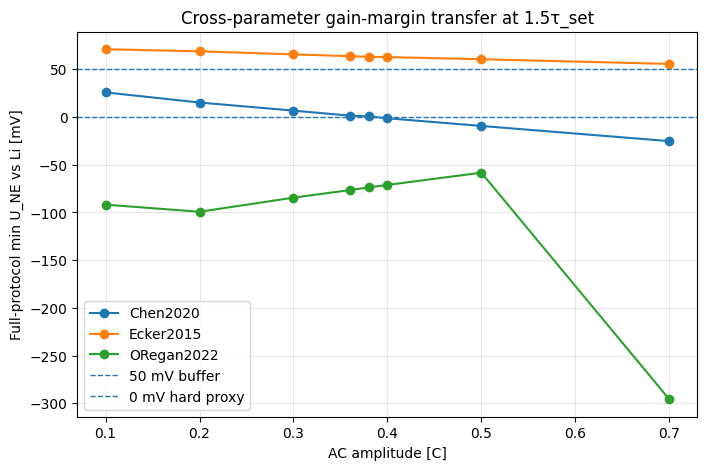

In [9]:
# Cell 9 — Plot cross-parameter AC-amplitude versus negative-electrode margin（绘制跨参数集幅值-负极余量）

plot_df = protocol_margin_summary_df[
    protocol_margin_summary_df["protocol_type"] == "DCAC"
].copy()

fig, ax = plt.subplots(figsize=(8, 5))

for pset, g in plot_df.groupby("parameter_set"):
    g = g.sort_values("ac_c")
    ax.plot(g["ac_c"], g["min_U_NE_vs_Li_mV"], marker="o", label=pset)

ax.axhline(50, linestyle="--", linewidth=1, label="50 mV buffer")
ax.axhline(0, linestyle="--", linewidth=1, label="0 mV hard proxy")

ax.set_xlabel("AC amplitude [C]")
ax.set_ylabel("Full-protocol min U_NE vs Li [mV]")
ax.set_title("Cross-parameter gain-margin transfer at 1.5τ_set")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

In [10]:
# Cell 10 — Cross-parameter transfer verdict table（跨参数集迁移判据表）

transfer_rows = []

for _, row in boundary_df.iterrows():
    pset = row["parameter_set"]
    g = protocol_margin_summary_df[protocol_margin_summary_df["parameter_set"] == pset].copy()
    
    dc_row = g[g["protocol_type"] == "DC"].iloc[0]
    dc_class = dc_row["margin_class"]
    dc_min = float(dc_row["min_U_NE_vs_Li_mV"])
    
    dcac = g[g["protocol_type"] == "DCAC"].copy()
    
    n_safe = int((dcac["margin_class"] == "safe_margin").sum())
    n_near = int((dcac["margin_class"] == "near_boundary").sum())
    n_risk = int((dcac["margin_class"] == "risk_flag").sum())
    
    if dc_class == "risk_flag":
        transfer_class = "baseline_risk_not_admissible_reference"
        interpretation = "DC reference already violates hard-margin proxy; not directly comparable for admissible-gain transfer."
    elif row["boundary_class"] == "within_scan_range":
        transfer_class = "boundary_within_scan"
        interpretation = "Hard-margin boundary occurs within scanned AC amplitudes."
    elif row["boundary_class"] == "above_scan_range":
        transfer_class = "all_scanned_amplitudes_admissible"
        interpretation = "No hard-margin crossing within scanned AC amplitudes."
    else:
        transfer_class = "unresolved"
        interpretation = "Transfer class unresolved."
    
    transfer_rows.append({
        "parameter_set": pset,
        "dc_min_U_NE_mV": dc_min,
        "dc_margin_class": dc_class,
        "n_scanned_DCAC": len(dcac),
        "n_safe_margin": n_safe,
        "n_near_boundary": n_near,
        "n_risk_flag": n_risk,
        "estimated_AC_C_at_0mV": row["estimated_AC_C_at_0mV"],
        "estimated_peak_C_at_0mV": row["estimated_peak_C_at_0mV"],
        "boundary_class": row["boundary_class"],
        "transfer_class": transfer_class,
        "interpretation": interpretation,
    })

transfer_verdict_df = pd.DataFrame(transfer_rows)

out = DATA_DIR / "day32_cross_parameter_transfer_verdict.csv"
transfer_verdict_df.to_csv(out, index=False)

print("[OK] saved:", out)
display(transfer_verdict_df)

[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day32_cross_parameter_transfer_verdict.csv


,parameter_set,dc_min_U_NE_mV,dc_margin_class,n_scanned_DCAC,n_safe_margin,n_near_boundary,n_risk_flag,estimated_AC_C_at_0mV,estimated_peak_C_at_0mV,boundary_class,transfer_class,interpretation
0,Chen2020,37.280562,near_boundary,8,0,5,3,0.38611,0.68611,within_scan_range,boundary_within_scan,Hard-margin boundary occurs within scanned AC ...
1,Ecker2015,73.618422,safe_margin,8,8,0,0,NaN,NaN,above_scan_range,all_scanned_amplitudes_admissible,No hard-margin crossing within scanned AC ampl...
2,ORegan2022,-98.368508,risk_flag,8,0,0,8,NaN,NaN,baseline_or_below_scan_range,baseline_risk_not_admissible_reference,DC reference already violates hard-margin prox...


## Interim conclusion — Parameter-set dependence of gain–margin admissibility

The cross-parameter transfer screen shows that the negative-electrode plating-margin boundary is not universal.

Chen2020 shows a clear hard-margin crossing inside the scanned AC-amplitude range. The estimated full-protocol hard-margin boundary is approximately `AC = 0.386C`, corresponding to `peak ≈ 0.686C`.

Ecker2015 remains above the 50 mV audit buffer for all scanned amplitudes up to `AC = 0.7C`. Under the current virtual three-electrode proxy, no hard-margin crossing is observed within the scanned range.

ORegan2022 is not directly comparable as an admissible transfer case because the `0.3C` DC reference is already below the 0 mV hard-margin proxy. It should be treated as a baseline-risk parameter set under the current protocol.

Therefore, the admissible DC–AC amplitude boundary is parameter-set dependent. The Chen2020 boundary must not be generalized as a universal DC–AC safety limit.

In [11]:
# Cell 11 — Geometry first-passage utilities（几何first-passage工具）

from scipy.optimize import brentq

def q_geom_charge_Ah(t_s, i_dc_A, i_ac_A=0.0, f_Hz=None):
    """
    Charge-positive current geometry:
    I_charge(t) = I_DC + I_AC sin(2πft)
    Q_geom(t) = ∫ I_charge dt / 3600
    """
    t_s = np.asarray(t_s, dtype=float)

    if i_ac_A == 0 or f_Hz is None or pd.isna(f_Hz):
        return i_dc_A * t_s / 3600.0

    omega = 2.0 * np.pi * f_Hz
    return (
        i_dc_A * t_s / 3600.0
        + i_ac_A / (omega * 3600.0) * (1.0 - np.cos(omega * t_s))
    )


def first_passage_geom_time_s(q_target_Ah, i_dc_A, i_ac_A=0.0, f_Hz=None, t_max_s=None):
    """
    First-passage time for prescribed current geometry.
    Handles non-monotonic Q(t) caused by AC discharge-like intervals.
    """
    if q_target_Ah < 0:
        return np.nan

    if i_ac_A == 0 or f_Hz is None or pd.isna(f_Hz):
        return q_target_Ah * 3600.0 / i_dc_A

    period_s = 1.0 / f_Hz

    if t_max_s is None:
        t_max_s = q_target_Ah * 3600.0 / max(i_dc_A, 1e-12) + 5.0 * period_s

    dt_s = min(period_s / 300.0, 2.0)
    dt_s = max(dt_s, 0.05)

    t_grid = np.arange(0.0, t_max_s + dt_s, dt_s)
    q_grid_geom = q_geom_charge_Ah(t_grid, i_dc_A, i_ac_A, f_Hz)

    hit = np.where(q_grid_geom >= q_target_Ah)[0]
    if len(hit) == 0:
        return np.nan

    idx = int(hit[0])
    if idx == 0:
        return float(t_grid[0])

    t0, t1 = float(t_grid[idx - 1]), float(t_grid[idx])

    def root_fun(t):
        return float(q_geom_charge_Ah(np.array([t]), i_dc_A, i_ac_A, f_Hz)[0] - q_target_Ah)

    try:
        return float(brentq(root_fun, t0, t1, maxiter=100))
    except ValueError:
        q0 = q_grid_geom[idx - 1]
        q1 = q_grid_geom[idx]
        if q1 == q0:
            return t1
        frac = (q_target_Ah - q0) / (q1 - q0)
        return float(t0 + frac * (t1 - t0))


def first_passage_time(t_s, q_Ah, q_target_Ah):
    t_s = np.asarray(t_s, dtype=float)
    q_Ah = np.asarray(q_Ah, dtype=float)

    hit = np.where(q_Ah >= q_target_Ah)[0]
    if len(hit) == 0:
        return np.nan

    i = int(hit[0])
    if i == 0:
        return float(t_s[0])

    q0, q1 = q_Ah[i - 1], q_Ah[i]
    t0, t1 = t_s[i - 1], t_s[i]

    if q1 == q0:
        return float(t1)

    frac = (q_target_Ah - q0) / (q1 - q0)
    return float(t0 + frac * (t1 - t0))

print("[OK] geometry and first-passage utilities ready")

[OK] geometry and first-passage utilities ready


In [12]:
# Cell 12 — Equal-Q timing and geometry-residual curves（等Q时间与几何-残差曲线）

equalq_dt_records = []

for pset in PARAMETER_SETS:
    dc_cond = f"{pset}_DFN_DC03"
    ts_dc = margin_ts_map[dc_cond]
    meta_dc = solutions[dc_cond]["meta"]

    pset_conditions = protocol_df[
        protocol_df["parameter_set"] == pset
    ].copy()

    # Common Q-grid per parameter set.
    q_end_by_cond = {
        row["condition"]: float(margin_ts_map[row["condition"]]["Q_net_Ah"].max())
        for _, row in pset_conditions.iterrows()
    }

    q_hi_raw = min(q_end_by_cond.values())
    q_grid = np.linspace(0.2, 0.95 * q_hi_raw, 100)

    for _, pr in pset_conditions.iterrows():
        cond = pr["condition"]
        if pr["protocol_type"] == "DC":
            continue

        ts_ac = margin_ts_map[cond]
        meta_ac = solutions[cond]["meta"]

        for q in q_grid:
            q = float(q)

            t_dc = first_passage_time(
                ts_dc["t_s"].to_numpy(),
                ts_dc["Q_net_Ah"].to_numpy(),
                q,
            )
            t_ac = first_passage_time(
                ts_ac["t_s"].to_numpy(),
                ts_ac["Q_net_Ah"].to_numpy(),
                q,
            )

            i_dc_A = float(meta_ac["i_dc_A"])
            i_ac_A = float(meta_ac["i_ac_A"])
            f_hz = None if pd.isna(pr["f_Hz"]) else float(pr["f_Hz"])

            t_dc_geom = first_passage_geom_time_s(
                q_target_Ah=q,
                i_dc_A=i_dc_A,
                i_ac_A=0.0,
                f_Hz=None,
            )
            t_ac_geom = first_passage_geom_time_s(
                q_target_Ah=q,
                i_dc_A=i_dc_A,
                i_ac_A=i_ac_A,
                f_Hz=f_hz,
            )

            delta_t_raw = t_dc - t_ac
            delta_t_geom = t_dc_geom - t_ac_geom
            delta_t_resid = delta_t_raw - delta_t_geom

            equalq_dt_records.append({
                "parameter_set": pset,
                "condition": cond,
                "reference_condition": dc_cond,
                "ac_c": float(pr["ac_c"]),
                "peak_c": float(pr["peak_c"]),
                "tau_factor_set": float(pr["tau_factor_set"]),
                "Q_Ah": q,
                "t_DC_s": t_dc,
                "t_DCAC_s": t_ac,
                "delta_t_raw_s": delta_t_raw,
                "t_DC_geom_s": t_dc_geom,
                "t_DCAC_geom_s": t_ac_geom,
                "delta_t_geom_s": delta_t_geom,
                "delta_t_resid_s": delta_t_resid,
            })

equalq_dt_df = pd.DataFrame(equalq_dt_records)

out = DATA_DIR / "day32_cross_parameter_equalQ_dt_geom_resid_curves.csv"
equalq_dt_df.to_csv(out, index=False)

print("[OK] saved:", out)
display(equalq_dt_df.head())


[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day32_cross_parameter_equalQ_dt_geom_resid_curves.csv


,parameter_set,condition,reference_condition,ac_c,peak_c,tau_factor_set,Q_Ah,t_DC_s,t_DCAC_s,delta_t_raw_s,t_DC_geom_s,t_DCAC_geom_s,delta_t_geom_s,delta_t_resid_s
0,Chen2020,Chen2020_DFN_DC03_AC0p1_1p5tauSet,Chen2020_DFN_DC03,0.1,0.4,1.5,0.200000,480.000000,453.580865,26.419135,480.000000,453.578973,26.421027,-0.001892
1,Chen2020,Chen2020_DFN_DC03_AC0p1_1p5tauSet,Chen2020_DFN_DC03,0.1,0.4,1.5,0.232851,558.842292,522.798810,36.043482,558.842292,522.794371,36.047922,-0.004439
2,Chen2020,Chen2020_DFN_DC03_AC0p1_1p5tauSet,Chen2020_DFN_DC03,0.1,0.4,1.5,0.265702,637.684584,629.048658,8.635927,637.684584,629.046995,8.637589,-0.001662
3,Chen2020,Chen2020_DFN_DC03_AC0p1_1p5tauSet,Chen2020_DFN_DC03,0.1,0.4,1.5,0.298553,716.526876,713.944597,2.582279,716.526876,713.946591,2.580285,0.001994
4,Chen2020,Chen2020_DFN_DC03_AC0p1_1p5tauSet,Chen2020_DFN_DC03,0.1,0.4,1.5,0.331404,795.369168,775.441804,19.927365,795.369168,775.440120,19.929048,-0.001683


In [13]:
# Cell 13 — Equal-Q timing / geometry-residual summary（等Q时间/几何-残差摘要）

dt_summary_df = (
    equalq_dt_df
    .groupby(["parameter_set", "condition", "ac_c", "peak_c", "tau_factor_set"], as_index=False)
    .agg(
        delta_t_raw_mean_s=("delta_t_raw_s", "mean"),
        delta_t_raw_min_s=("delta_t_raw_s", "min"),
        delta_t_raw_max_s=("delta_t_raw_s", "max"),
        delta_t_geom_mean_s=("delta_t_geom_s", "mean"),
        delta_t_geom_min_s=("delta_t_geom_s", "min"),
        delta_t_geom_max_s=("delta_t_geom_s", "max"),
        delta_t_resid_mean_s=("delta_t_resid_s", "mean"),
        delta_t_resid_min_s=("delta_t_resid_s", "min"),
        delta_t_resid_max_s=("delta_t_resid_s", "max"),
        resid_abs_mean_s=("delta_t_resid_s", lambda x: np.nanmean(np.abs(x))),
        resid_max_abs_s=("delta_t_resid_s", lambda x: np.nanmax(np.abs(x))),
    )
)

dt_summary_df["resid_over_raw_mean"] = (
    dt_summary_df["delta_t_resid_mean_s"]
    / dt_summary_df["delta_t_raw_mean_s"].replace(0, np.nan)
)

def classify_dt_resid(row):
    raw = abs(row["delta_t_raw_mean_s"])
    resid_abs = row["resid_abs_mean_s"]

    if not np.isfinite(raw) or raw < 1:
        return "near_zero_or_unresolved"

    ratio = resid_abs / raw

    if ratio < 0.05:
        return "geometry_dominated"
    if ratio < 0.20:
        return "mostly_geometry_small_residual"
    return "residual_non_negligible"

dt_summary_df["dt_resid_class"] = dt_summary_df.apply(classify_dt_resid, axis=1)

out = DATA_DIR / "day32_cross_parameter_dt_geom_resid_summary.csv"
dt_summary_df.to_csv(out, index=False)

print("[OK] saved:", out)
display(dt_summary_df.sort_values(["parameter_set", "ac_c"]))


[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day32_cross_parameter_dt_geom_resid_summary.csv


,parameter_set,condition,ac_c,peak_c,tau_factor_set,delta_t_raw_mean_s,delta_t_raw_min_s,delta_t_raw_max_s,delta_t_geom_mean_s,delta_t_geom_min_s,delta_t_geom_max_s,delta_t_resid_mean_s,delta_t_resid_min_s,delta_t_resid_max_s,resid_abs_mean_s,resid_max_abs_s,resid_over_raw_mean,dt_resid_class
0,Chen2020,Chen2020_DFN_DC03_AC0p1_1p5tauSet,0.10,0.40,1.5,18.155482,0.001039,36.311196,18.158348,0.000954,36.316315,-0.002866,-0.008121,0.001994,0.002961,0.008121,-0.000158,geometry_dominated
1,Chen2020,Chen2020_DFN_DC03_AC0p2_1p5tauSet,0.20,0.50,1.5,36.370609,-0.002290,72.598919,36.378077,0.001916,72.604905,-0.007469,-0.034177,0.002648,0.007544,0.034177,-0.000205,geometry_dominated
4,Chen2020,Chen2020_DFN_DC03_AC0p3_1p5tauSet,0.30,0.60,1.5,53.953401,-0.005049,108.884627,53.970110,0.002883,108.903702,-0.016709,-0.565160,0.001755,0.016764,0.565160,-0.000310,geometry_dominated
2,Chen2020,Chen2020_DFN_DC03_AC0p36_1p5tauSet,0.36,0.66,1.5,66.913899,-0.011621,130.317604,66.927220,0.003467,130.335009,-0.013321,-0.053940,0.006423,0.013449,0.053940,-0.000199,geometry_dominated
3,Chen2020,Chen2020_DFN_DC03_AC0p38_1p5tauSet,0.38,0.68,1.5,69.349504,-0.015226,137.956760,69.363415,0.003662,138.002801,-0.013911,-0.046040,0.005885,0.014029,0.046040,-0.000201,geometry_dominated
5,Chen2020,Chen2020_DFN_DC03_AC0p4_1p5tauSet,0.40,0.70,1.5,75.416853,-0.018275,145.236918,75.445819,0.003858,145.265136,-0.028965,-1.281532,0.002256,0.029011,1.281532,-0.000384,geometry_dominated
6,Chen2020,Chen2020_DFN_DC03_AC0p5_1p5tauSet,0.50,0.80,1.5,102.862474,6.879782,181.187890,102.878609,6.880400,181.201473,-0.016135,-0.125253,0.002746,0.016191,0.125253,-0.000157,geometry_dominated
7,Chen2020,Chen2020_DFN_DC03_AC0p7_1p5tauSet,0.70,1.00,1.5,158.670924,48.447088,254.168140,158.685939,48.460614,254.200254,-0.015015,-0.051294,-0.001304,0.015015,0.051294,-0.000095,geometry_dominated
8,Ecker2015,Ecker2015_DFN_DC03_AC0p1_1p5tauSet,0.10,0.40,1.5,8.450602,0.045453,16.482190,8.318227,0.001095,16.515285,-0.028945,-0.049262,-0.017050,0.028945,0.049262,-0.003425,geometry_dominated
9,Ecker2015,Ecker2015_DFN_DC03_AC0p2_1p5tauSet,0.20,0.50,1.5,16.201744,0.157434,33.024853,16.698137,0.002203,33.025918,0.010213,-0.001593,0.033611,0.010453,0.033611,0.000630,geometry_dominated


In [14]:
# Cell 14 — Merge timing, margin, and transfer verdict（合并时间、析锂余量与迁移判据）

gain_margin_transfer_df = (
    dt_summary_df
    .merge(
        protocol_margin_summary_df[
            [
                "parameter_set",
                "condition",
                "min_U_NE_vs_Li_mV",
                "fraction_time_below_50mV",
                "fraction_time_below_0mV",
                "margin_class",
            ]
        ],
        on=["parameter_set", "condition"],
        how="left",
    )
    .merge(
        transfer_verdict_df[
            [
                "parameter_set",
                "dc_margin_class",
                "estimated_AC_C_at_0mV",
                "estimated_peak_C_at_0mV",
                "transfer_class",
            ]
        ],
        on="parameter_set",
        how="left",
    )
)

def classify_gain_margin(row):
    if row["margin_class"] == "risk_flag":
        margin_part = "risk"
    elif row["margin_class"] == "near_boundary":
        margin_part = "near_boundary"
    elif row["margin_class"] == "safe_margin":
        margin_part = "safe_margin"
    else:
        margin_part = "unresolved_margin"

    if row["dt_resid_class"] == "geometry_dominated":
        timing_part = "geometry_gain"
    elif row["dt_resid_class"] == "mostly_geometry_small_residual":
        timing_part = "mostly_geometry_gain"
    else:
        timing_part = "residual_or_unresolved"

    return f"{timing_part}__{margin_part}"

gain_margin_transfer_df["gain_margin_class"] = gain_margin_transfer_df.apply(
    classify_gain_margin,
    axis=1,
)

out = DATA_DIR / "day32_cross_parameter_gain_margin_transfer_summary.csv"
gain_margin_transfer_df.to_csv(out, index=False)

print("[OK] saved:", out)

cols = [
    "parameter_set",
    "ac_c",
    "peak_c",
    "delta_t_raw_mean_s",
    "delta_t_geom_mean_s",
    "delta_t_resid_mean_s",
    "resid_abs_mean_s",
    "dt_resid_class",
    "min_U_NE_vs_Li_mV",
    "fraction_time_below_50mV",
    "fraction_time_below_0mV",
    "margin_class",
    "estimated_AC_C_at_0mV",
    "transfer_class",
    "gain_margin_class",
]

display(gain_margin_transfer_df[cols].sort_values(["parameter_set", "ac_c"]))

[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day32_cross_parameter_gain_margin_transfer_summary.csv


,parameter_set,ac_c,peak_c,delta_t_raw_mean_s,delta_t_geom_mean_s,delta_t_resid_mean_s,resid_abs_mean_s,dt_resid_class,min_U_NE_vs_Li_mV,fraction_time_below_50mV,fraction_time_below_0mV,margin_class,estimated_AC_C_at_0mV,transfer_class,gain_margin_class
0,Chen2020,0.10,0.40,18.155482,18.158348,-0.002866,0.002961,geometry_dominated,25.760879,0.155802,0.000000,near_boundary,0.38611,boundary_within_scan,geometry_gain__near_boundary
1,Chen2020,0.20,0.50,36.370609,36.378077,-0.007469,0.007544,geometry_dominated,15.144144,0.142246,0.000000,near_boundary,0.38611,boundary_within_scan,geometry_gain__near_boundary
4,Chen2020,0.30,0.60,53.953401,53.970110,-0.016709,0.016764,geometry_dominated,6.661005,0.128721,0.000000,near_boundary,0.38611,boundary_within_scan,geometry_gain__near_boundary
2,Chen2020,0.36,0.66,66.913899,66.927220,-0.013321,0.013449,geometry_dominated,1.432702,0.130886,0.000000,near_boundary,0.38611,boundary_within_scan,geometry_gain__near_boundary
3,Chen2020,0.38,0.68,69.349504,69.363415,-0.013911,0.014029,geometry_dominated,0.584036,0.145062,0.000000,near_boundary,0.38611,boundary_within_scan,geometry_gain__near_boundary
5,Chen2020,0.40,0.70,75.416853,75.445819,-0.028965,0.029011,geometry_dominated,-1.327813,0.156143,0.002733,risk_flag,0.38611,boundary_within_scan,geometry_gain__risk
6,Chen2020,0.50,0.80,102.862474,102.878609,-0.016135,0.016191,geometry_dominated,-9.386875,0.186843,0.018540,risk_flag,0.38611,boundary_within_scan,geometry_gain__risk
7,Chen2020,0.70,1.00,158.670924,158.685939,-0.015015,0.015015,geometry_dominated,-25.298691,0.222304,0.039973,risk_flag,0.38611,boundary_within_scan,geometry_gain__risk
8,Ecker2015,0.10,0.40,8.450602,8.318227,-0.028945,0.028945,geometry_dominated,70.986082,0.000000,0.000000,safe_margin,NaN,all_scanned_amplitudes_admissible,geometry_gain__safe_margin
9,Ecker2015,0.20,0.50,16.201744,16.698137,0.010213,0.010453,geometry_dominated,68.760946,0.000000,0.000000,safe_margin,NaN,all_scanned_amplitudes_admissible,geometry_gain__safe_margin


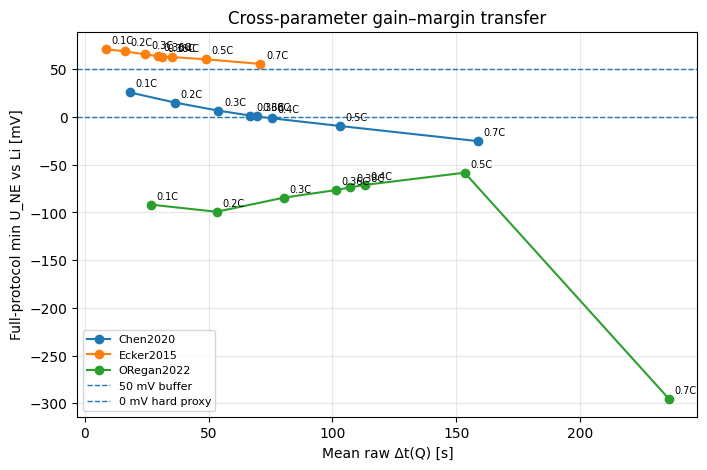

In [15]:
# Cell 15 — Plot raw timing gain versus plating margin across parameter sets（绘制跨参数集时间收益-析锂余量图）

plot_df = gain_margin_transfer_df.copy()

fig, ax = plt.subplots(figsize=(8, 5))

for pset, g in plot_df.groupby("parameter_set"):
    g = g.sort_values("ac_c")
    ax.plot(
        g["delta_t_raw_mean_s"],
        g["min_U_NE_vs_Li_mV"],
        marker="o",
        label=pset,
    )

    for _, row in g.iterrows():
        ax.annotate(
            f"{row['ac_c']:.2g}C",
            (row["delta_t_raw_mean_s"], row["min_U_NE_vs_Li_mV"]),
            textcoords="offset points",
            xytext=(4, 4),
            fontsize=7,
        )

ax.axhline(50, linestyle="--", linewidth=1, label="50 mV buffer")
ax.axhline(0, linestyle="--", linewidth=1, label="0 mV hard proxy")

ax.set_xlabel("Mean raw Δt(Q) [s]")
ax.set_ylabel("Full-protocol min U_NE vs Li [mV]")
ax.set_title("Cross-parameter gain–margin transfer")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
plt.show()